<a href="https://colab.research.google.com/github/krskumarsatyam777-glitch/News-headline-sarcasm-detector/blob/main/notebook/news_headline_sarcasm_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q transformers datasets evaluate wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00


In [3]:
!pip install -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 14.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0


In [4]:
# import all the required libraries
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import CountVectorizer

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
#import the dataframe
df= pd.read_json('/content/SarcasmDetect.json', lines=True)

In [6]:
df.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


#  **EXPLORATORY DATA ANALYSIS**




In [7]:
df.shape

(28619, 3)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB


In [9]:
df.isnull().sum()

,0
is_sarcastic,0
headline,0
article_link,0


check for duplicates

In [10]:
# full row duplicates
print(df.duplicated().sum())
 # headline-only duplicates
print(df.duplicated(subset='headline').sum())

2
116


In [11]:
# deleting the duplicates
df = df.drop_duplicates(subset='headline').reset_index(drop=True)

In [12]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28503 entries, 0 to 28502
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28503 non-null  int64 
 1   headline      28503 non-null  object
 2   article_link  28503 non-null  object
dtypes: int64(1), object(2)
memory usage: 668.2+ KB


class distribution

is_sarcastic
0    0.524541
1    0.475459
Name: proportion, dtype: float64


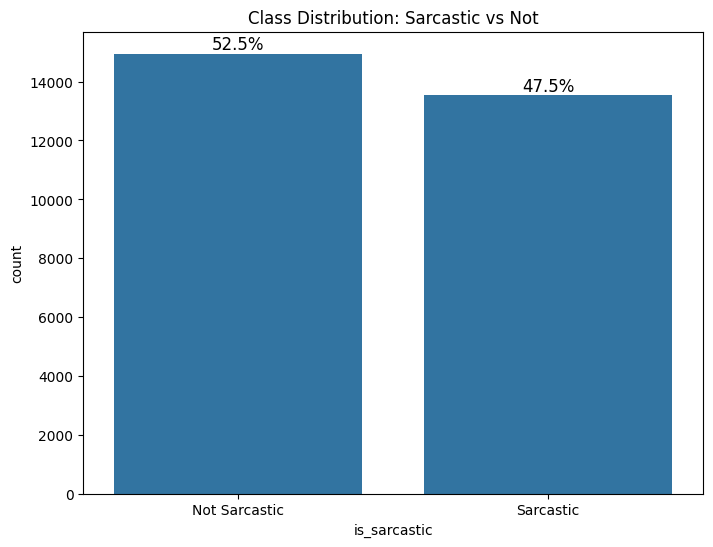

In [13]:
print(df['is_sarcastic'].value_counts(normalize=True))

plt.figure(figsize=(8, 6))
ax = sns.countplot(x=df['is_sarcastic'])

# Calculate percentages and annotate bars
total = len(df['is_sarcastic'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

plt.title('Class Distribution: Sarcastic vs Not')
plt.xticks([0, 1], ['Not Sarcastic', 'Sarcastic'])
plt.show()

### **Insights**
- The dataset is **nearly balanced**, with **52.5% Not Sarcastic** and **47.5% Sarcastic** headlines.
- No significant class imbalance is observed, minimizing the risk of model bias.
- No resampling techniques (oversampling/undersampling) are required.
- The balanced distribution is suitable for reliable model training and evaluation.

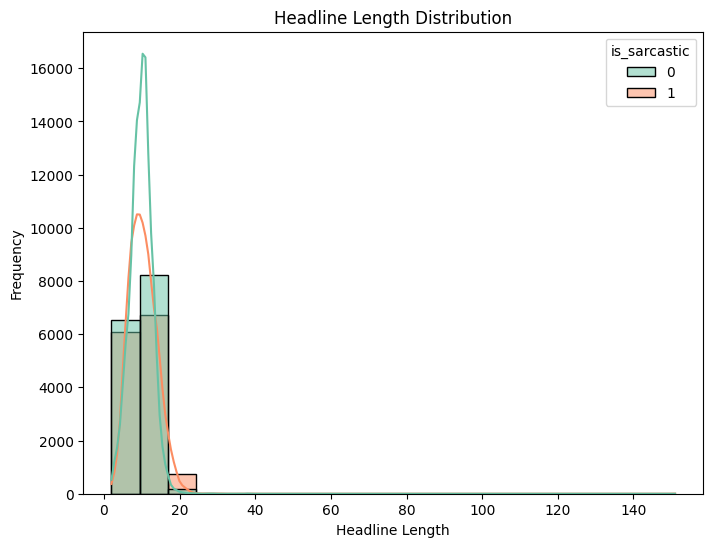

In [14]:
# headline length
df['word count'] = df['headline'].str.split().str.len()
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='word count', bins=20, kde=True , hue='is_sarcastic', palette = 'Set2')
plt.xlabel('Headline Length')
plt.ylabel('Frequency')
plt.title('Headline Length Distribution')
plt.show()

### **Insights**
- Most headlines contain **5–15 words**, indicating a consistent headline length.
- Both classes show a **similar length distribution**, suggesting headline length alone is not a strong indicator of sarcasm.
- A few longer headlines are present, but they represent **rare outliers**.

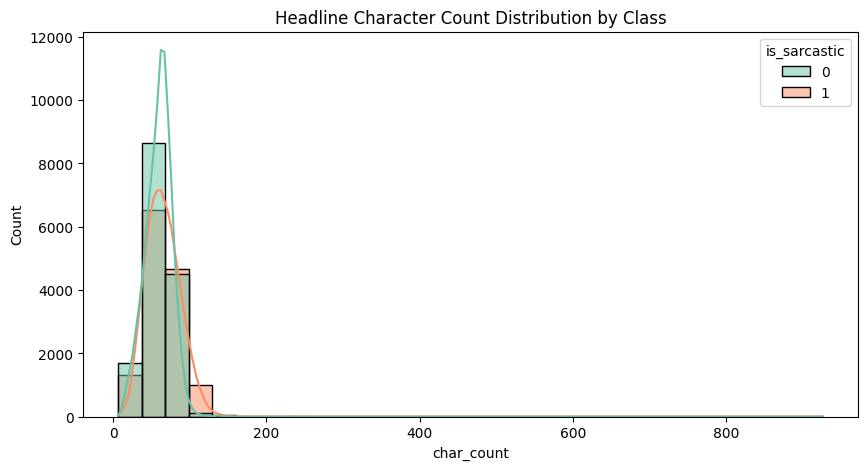

,count,mean,std,min,25%,50%,75%,max
is_sarcastic,,,,,,,,
0,14951.0,59.615143,17.281590,7.0,48.0,61.0,71.0,228.0
1,13552.0,65.430785,23.549612,8.0,49.0,64.0,80.0,926.0


In [15]:
# Character count as a second length signal alongside word_count
df['char_count'] = df['headline'].str.len()

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='char_count', hue='is_sarcastic', bins=30, kde=True, palette='Set2')
plt.title('Headline Character Count Distribution by Class')
plt.show()

df.groupby('is_sarcastic')['char_count'].describe()

### **Insights**
- Most headlines contain **40–80 characters**, showing a consistent character length.
- Both classes exhibit **similar character count distributions**, indicating that character count alone is not a strong predictor of sarcasm.
- A few headlines have exceptionally high character counts, representing **rare outliers**.

In [16]:
#source domain check
df['source'] = df['article_link'].str.extract(r'https?://([^/]+)/')
pd.crosstab(df['source'].apply(lambda x: 'theonion' in str(x)), df['is_sarcastic'])

is_sarcastic,0,1
source,,
False,14951,0
True,0,13552


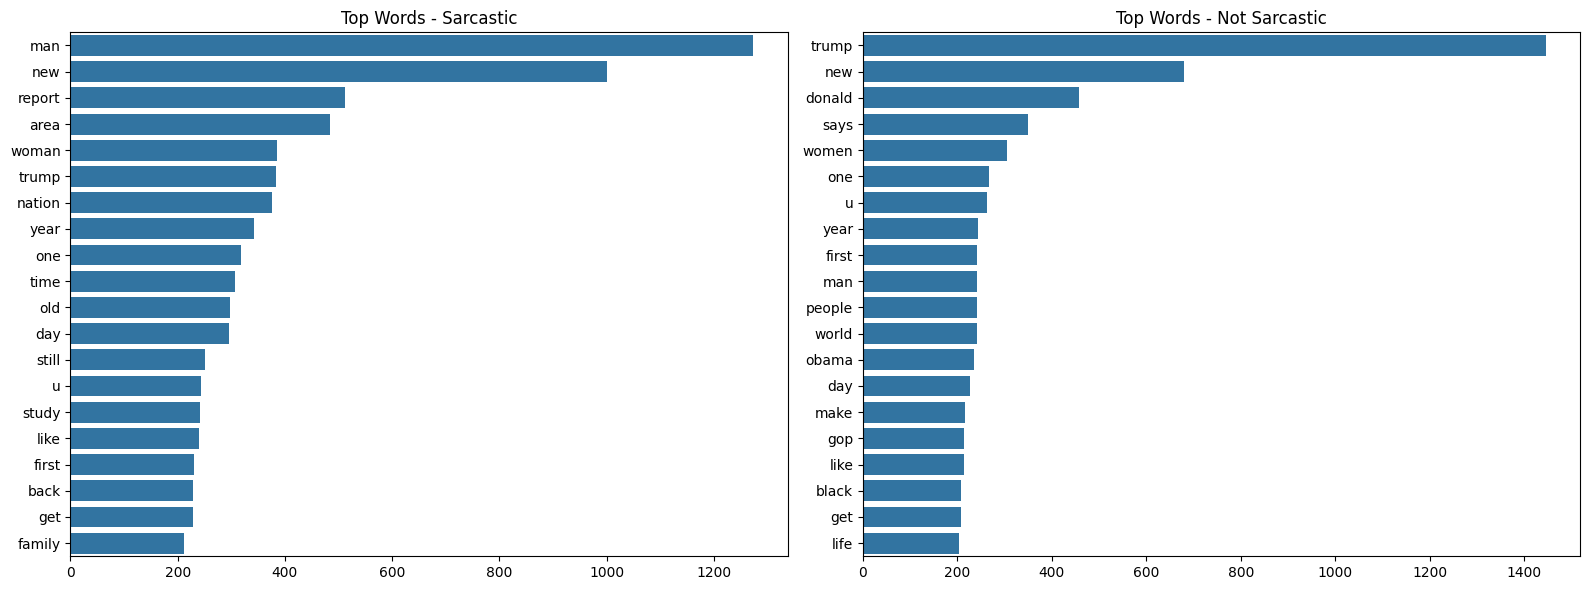

In [17]:
#most frequent words per class
stop_words = set(stopwords.words('english'))

def get_top_words(text_series, n=20):
    words = []
    for text in text_series:
        tokens = re.findall(r'\b[a-z]+\b', text.lower())
        words.extend([w for w in tokens if w not in stop_words])
    return Counter(words).most_common(n)

sarcastic_words = get_top_words(df[df['is_sarcastic']==1]['headline'])
not_sarcastic_words = get_top_words(df[df['is_sarcastic']==0]['headline'])

fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.barplot(x=[c for w,c in sarcastic_words], y=[w for w,c in sarcastic_words], ax=axes[0])
axes[0].set_title('Top Words - Sarcastic')

sns.barplot(x=[c for w,c in not_sarcastic_words], y=[w for w,c in not_sarcastic_words], ax=axes[1])
axes[1].set_title('Top Words - Not Sarcastic')
plt.tight_layout()
plt.show()

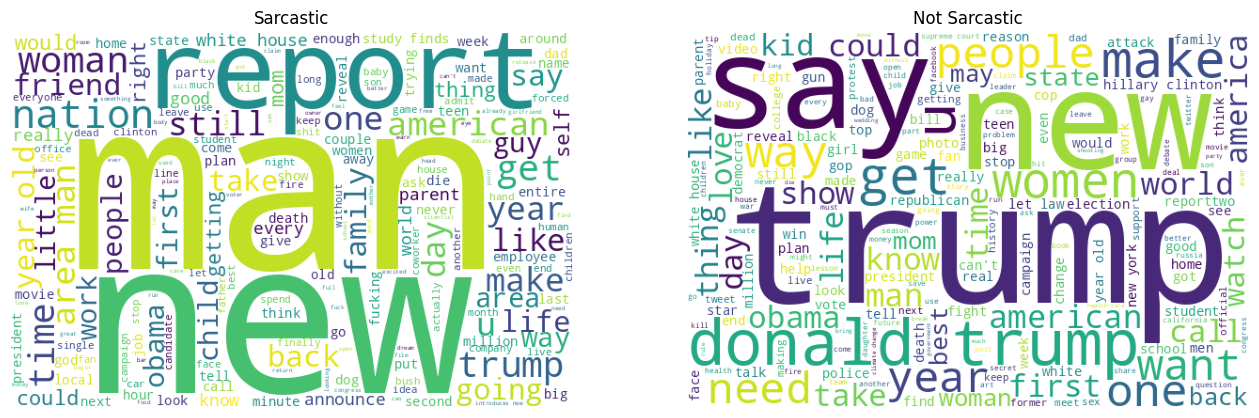

In [18]:
#word clouds
fig, axes = plt.subplots(1, 2, figsize=(16,8))
for ax, label, title in zip(axes, [1,0], ['Sarcastic', 'Not Sarcastic']):
    text = ' '.join(df[df['is_sarcastic']==label]['headline'])
    wc = WordCloud(width=600, height=400, background_color='white', stopwords=stop_words).generate(text)
    ax.imshow(wc)
    ax.set_title(title)
    ax.axis('off')
plt.show()

### **Insights**
- Both classes share several common high-frequency words.
- Frequent words alone do not clearly differentiate sarcastic and non-sarcastic headlines.
- Contextual information is likely more important than individual word frequency for sarcasm detection.

Bigram analysis

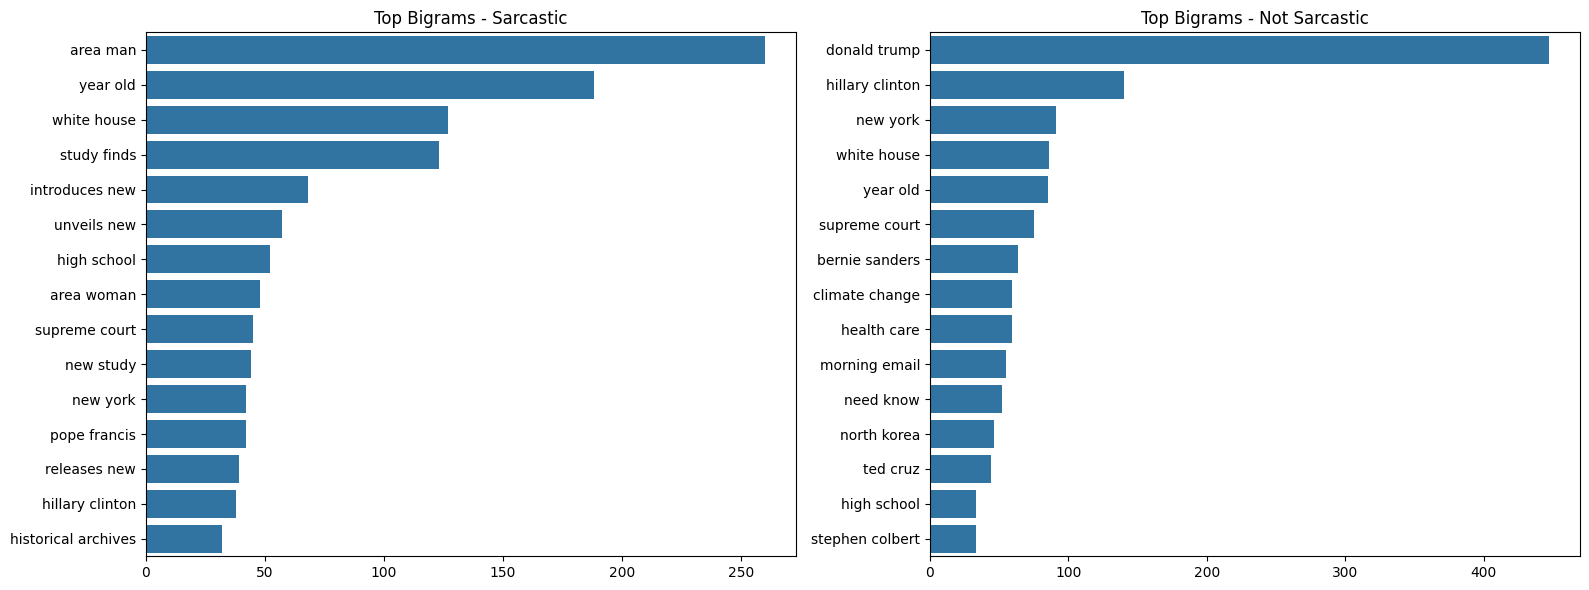

In [19]:
def get_top_bigrams(text_series, n=15):
    vec = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=1000)
    bigram_matrix = vec.fit_transform(text_series)
    counts = bigram_matrix.sum(axis=0).A1
    bigram_freq = list(zip(vec.get_feature_names_out(), counts))
    return sorted(bigram_freq, key=lambda x: x[1], reverse=True)[:n]

sarcastic_bigrams = get_top_bigrams(df[df['is_sarcastic']==1]['headline'])
not_sarcastic_bigrams = get_top_bigrams(df[df['is_sarcastic']==0]['headline'])

fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.barplot(x=[c for w,c in sarcastic_bigrams], y=[w for w,c in sarcastic_bigrams], ax=axes[0])
axes[0].set_title('Top Bigrams - Sarcastic')
sns.barplot(x=[c for w,c in not_sarcastic_bigrams], y=[w for w,c in not_sarcastic_bigrams], ax=axes[1])
axes[1].set_title('Top Bigrams - Not Sarcastic')
plt.tight_layout()
plt.show()

### **Insights**
- Both classes exhibit a similar bigram distribution, with several common news-related phrases appearing in both.
- Bigram frequency alone is insufficient to distinguish sarcasm, highlighting the need for contextual language understanding.

              num_exclaim  num_question  num_quotes
is_sarcastic                                       
0                0.011504      0.049161    0.007491
1                0.002878      0.007600    0.001107


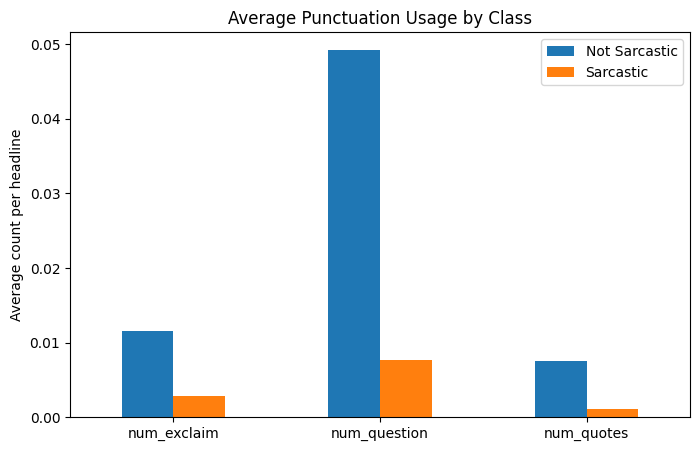

In [20]:
# Count punctuation marks that might signal tone
df['num_exclaim'] = df['headline'].str.count('!')
df['num_question'] = df['headline'].str.count(r'\?')
df['num_quotes'] = df['headline'].str.count('"')

punct_summary = df.groupby('is_sarcastic')[['num_exclaim', 'num_question', 'num_quotes']].mean()
print(punct_summary)

punct_summary.T.plot(kind='bar', figsize=(8,5))
plt.title('Average Punctuation Usage by Class')
plt.ylabel('Average count per headline')
plt.xticks(rotation=0)
plt.legend(['Not Sarcastic', 'Sarcastic'])
plt.show()

### **Insights**
- Non-sarcastic headlines show slightly higher usage of punctuation marks than sarcastic headlines.
- Overall punctuation usage remains low, indicating that contextual language features are more important for sarcasm detection.

# **Data Preprocessing**

In [21]:
df.head()

,is_sarcastic,headline,article_link,word count,char_count,source,num_exclaim,num_question,num_quotes
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...,8,61,www.theonion.com,0,0,0
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...,13,79,www.huffingtonpost.com,0,0,0
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...,7,49,www.huffingtonpost.com,0,0,0
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...,8,52,local.theonion.com,0,0,0
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...,9,61,www.theonion.com,0,0,0


In [22]:
df['headline'] = df['headline'].str.lower().str.strip()

In [23]:
df=df.drop(columns=['article_link','num_exclaim', 'num_question', 'num_quotes','word count','char_count'])

In [24]:
df.head()

,is_sarcastic,headline,source
0,1,thirtysomething scientists unveil doomsday clo...,www.theonion.com
1,0,dem rep. totally nails why congress is falling...,www.huffingtonpost.com
2,0,eat your veggies: 9 deliciously different recipes,www.huffingtonpost.com
3,1,inclement weather prevents liar from getting t...,local.theonion.com
4,1,mother comes pretty close to using word 'strea...,www.theonion.com


In [25]:
# train test split
X = df['headline']
y = df['is_sarcastic']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 19952, Val: 4275, Test: 4276


# **Model evaluation Criterion**

In [26]:
def metric_score(actual, predicted, labels=['Not Sarcastic', 'Sarcastic']):
    print(classification_report(actual, predicted, target_names=labels))
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels, yticklabels=labels)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

# **LOGISTIC REGRESSION**(BASELINE MODEL)

TF-IDF Vectorization

In [27]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# Check feature matrix shapes
print("Train TF-IDF Shape:", X_train_tfidf.shape)
print("Validation TF-IDF Shape:", X_val_tfidf.shape)
print("Test TF-IDF Shape:", X_test_tfidf.shape)

Train TF-IDF Shape: (19952, 5000)
Validation TF-IDF Shape: (4275, 5000)
Test TF-IDF Shape: (4276, 5000)


In [28]:
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

LogisticRegression()

               precision    recall  f1-score   support

Not Sarcastic       0.84      0.89      0.87     10466
    Sarcastic       0.87      0.82      0.84      9486

     accuracy                           0.86     19952
    macro avg       0.86      0.85      0.85     19952
 weighted avg       0.86      0.86      0.86     19952



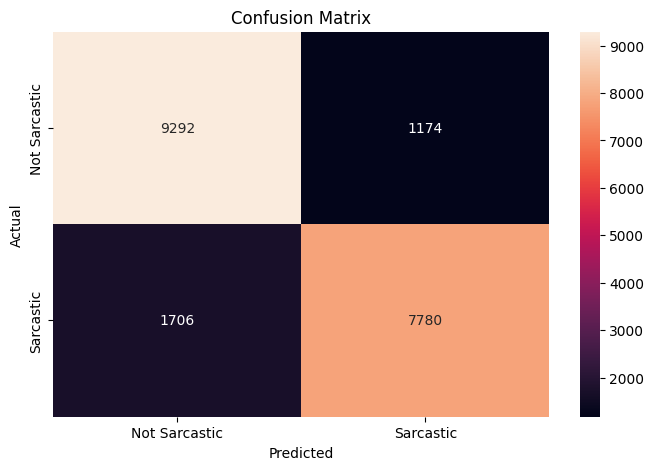

In [29]:
#check the performance on training dataset
y_train_pred = lr.predict(X_train_tfidf)
metric_score(y_train, y_train_pred)

               precision    recall  f1-score   support

Not Sarcastic       0.77      0.81      0.79      2243
    Sarcastic       0.78      0.73      0.75      2033

     accuracy                           0.77      4276
    macro avg       0.77      0.77      0.77      4276
 weighted avg       0.77      0.77      0.77      4276



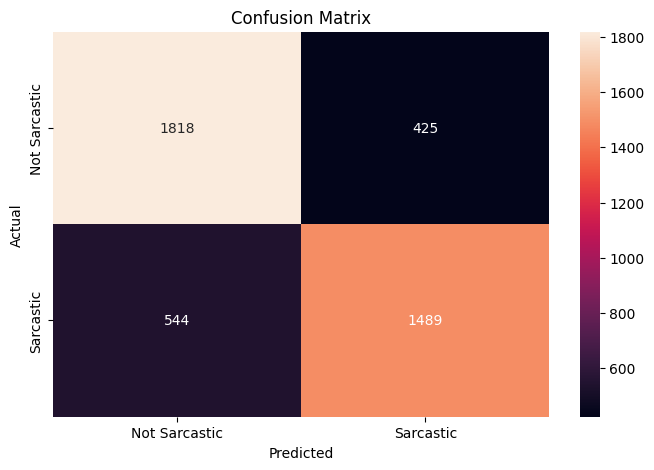

In [30]:
#check the performance on testing dataset
y_test_pred = lr.predict(X_test_tfidf)
metric_score(y_test, y_test_pred)

### **Observations**
- The Logistic Regression model achieved **86% accuracy on the training set** and **77% accuracy on the test set**, indicating good learning but a moderate degree of overfitting.
- Precision, recall, and F1-scores are relatively balanced across both classes, showing that the model does not exhibit significant bias toward either class.
- The confusion matrices indicate that most headlines are classified correctly; however, a noticeable number of sarcastic headlines are misclassified, suggesting that TF-IDF-based features struggle to capture the contextual and semantic nuances of sarcasm.
- Overall, Logistic Regression with TF-IDF serves as a strong baseline, but the observed performance gap and misclassifications motivate the use of contextual transformer-based models.


# **Hyperparameter Tuning — Logistic Regression (TF-IDF: Unigram + Bigram)**

In [37]:
# TF-IDF with unigrams + bigrams
tfidf_tuned = TfidfVectorizer(stop_words='english', max_features=5000, min_df=2, ngram_range=(1,2))

X_train_tfidf_v2 = tfidf_tuned.fit_transform(X_train)
X_val_tfidf_v2 = tfidf_tuned.transform(X_val)
X_test_tfidf_v2 = tfidf_tuned.transform(X_test)

In [45]:
# tune C on the validation set
C_values = [0.5, 0.75, 1, 1.5, 2, 2.5, 3, 3.5, 5, 7]
val_scores = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train_tfidf_v2, y_train)
    pred = model.predict(X_val_tfidf_v2)
    score = f1_score(y_val, pred, average='weighted')
    val_scores.append(score)
    print('C =', C, '-> val F1 =', round(score, 4))

best_C = C_values[val_scores.index(max(val_scores))]
print('best C:', best_C)

C = 0.5 -> val F1 = 0.7762
C = 0.75 -> val F1 = 0.7813
C = 1 -> val F1 = 0.7833
C = 1.5 -> val F1 = 0.7853
C = 2 -> val F1 = 0.7856
C = 2.5 -> val F1 = 0.7866
C = 3 -> val F1 = 0.7859
C = 3.5 -> val F1 = 0.7862
C = 5 -> val F1 = 0.7844
C = 7 -> val F1 = 0.7821
best C: 2.5


In [46]:
lr_tuned = LogisticRegression(C=best_C, max_iter=1000)
lr_tuned.fit(X_train_tfidf_v2, y_train)

LogisticRegression(C=2.5, max_iter=1000)

Tuned Logistic Regression — Training Performance:
               precision    recall  f1-score   support

Not Sarcastic       0.87      0.90      0.88     10466
    Sarcastic       0.88      0.85      0.87      9486

     accuracy                           0.88     19952
    macro avg       0.88      0.87      0.88     19952
 weighted avg       0.88      0.88      0.88     19952



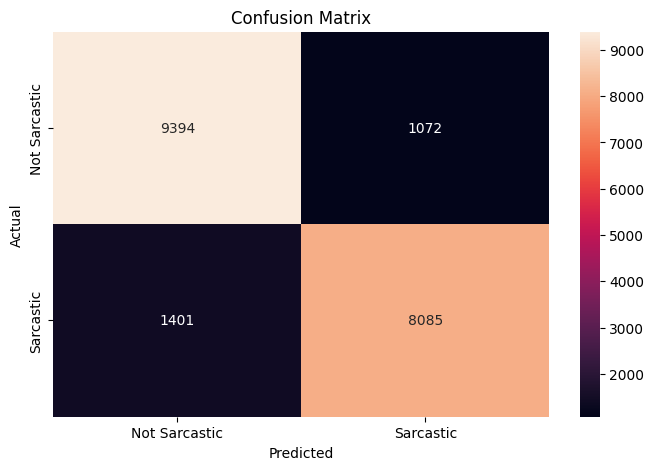

In [47]:
# check the performance on training dataset
y_train_pred_tuned = lr_tuned.predict(X_train_tfidf_v2)
print("Tuned Logistic Regression — Training Performance:")
metric_score(y_train, y_train_pred_tuned)

Tuned Logistic Regression — Test Performance:
               precision    recall  f1-score   support

Not Sarcastic       0.77      0.80      0.79      2243
    Sarcastic       0.77      0.74      0.76      2033

     accuracy                           0.77      4276
    macro avg       0.77      0.77      0.77      4276
 weighted avg       0.77      0.77      0.77      4276



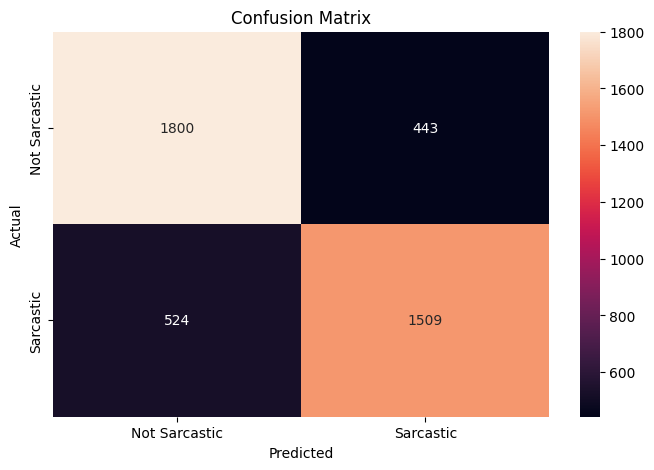

In [48]:
# check the performance on testing dataset
y_test_pred_tuned = lr_tuned.predict(X_test_tfidf_v2)
print("Tuned Logistic Regression — Test Performance:")
metric_score(y_test, y_test_pred_tuned)

### **Observations**
- Added bigrams to the features and tuned `C` (controls regularization — lower means stronger regularization) using the validation set, landing on `C=2.5`.
- Training accuracy went up (86% → 88%), but test accuracy stayed the same at 77% — so the model fit the training data better without actually generalizing better.
- Recall and F1 for the sarcastic class improved a little (0.73 → 0.74 and 0.75 → 0.76), but non-sarcastic recall dropped slightly (0.81 → 0.80).
- The train-test gap grew a bit (9 → 11 points), likely because bigrams add a lot of sparse, specific features that don't carry over well to new headlines.
- Overall, bigrams didn't really move the needle here — TF-IDF still can't pick up on the deeper context that sarcasm needs.

# **DistilBERT Classifier**

In [49]:
#convert the pandas dataset into Hugging face dataset objects
train_dataset = Dataset.from_pandas(pd.DataFrame({'headline': list(X_train), 'label': list(y_train)}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'headline': list(X_val), 'label': list(y_val)}))
test_dataset = Dataset.from_pandas(pd.DataFrame({'headline': list(X_test), 'label': list(y_test)}))

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['headline', 'label'],
    num_rows: 19952
})
Dataset({
    features: ['headline', 'label'],
    num_rows: 4275
})
Dataset({
    features: ['headline', 'label'],
    num_rows: 4276
})


loading tokenizer and tokenizing the datset

In [50]:
checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_function(batch):
    return tokenizer(batch['headline'], truncation=True, padding='max_length', max_length=64)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

print(train_tokenized)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/19952 [00:00<?, ? examples/s]

Map:   0%|          | 0/4275 [00:00<?, ? examples/s]

Map:   0%|          | 0/4276 [00:00<?, ? examples/s]

Dataset({
    features: ['headline', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 19952
})


In [51]:
# Load pretrained DistilBERT with a classification head on top
# num_labels=2 adds a 2-neuron output layer for binary classification
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [52]:
# Load accuracy and f1 metrics from Huggingface evaluate library
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

# Define the evaluation function
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  accuracy_score = accuracy.compute(predictions=predictions, references=labels)
  f1_score = f1.compute(predictions=predictions, references=labels, average='weighted')
  return {**accuracy_score, **f1_score}

In [53]:
#defining all hyperparameters and training behaviour

training_args = TrainingArguments(
    output_dir="./sarcasm-distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=.01,
    load_best_model_at_end= True,
    metric_for_best_model="f1",
    logging_steps=50,
)

In [54]:
# training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.228089,0.207011,0.914854,0.914669
2,0.137676,0.182124,0.931462,0.931456
3,0.069061,0.230396,0.931462,0.931376


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1872, training_loss=0.17583757021233568, metrics={'train_runtime': 383.5618, 'train_samples_per_second': 156.053, 'train_steps_per_second': 4.881, 'total_flos': 991121076744192.0, 'train_loss': 0.17583757021233568, 'epoch': 3.0})

### **Observations**
- Validation accuracy went from 91.5% (epoch 1) to 93.1% (epoch 2), and stayed at 93.1% in epoch 3 — most of the learning happened in the first two epochs.
- Epoch 2 had the lowest validation loss (0.182) and the best F1 score (0.9315), so `Trainer` kept epoch 2's weights as the final model.
- In epoch 3, training loss kept dropping (0.137 → 0.069) but validation loss went back up (0.182 → 0.230) — a clear sign of overfitting starting to kick in.

In [70]:
#predicting on test dataset
predictions = trainer.predict(test_tokenized)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

DistilBERT Test Performance:
               precision    recall  f1-score   support

Not Sarcastic       0.93      0.92      0.92      2243
    Sarcastic       0.91      0.92      0.92      2033

     accuracy                           0.92      4276
    macro avg       0.92      0.92      0.92      4276
 weighted avg       0.92      0.92      0.92      4276



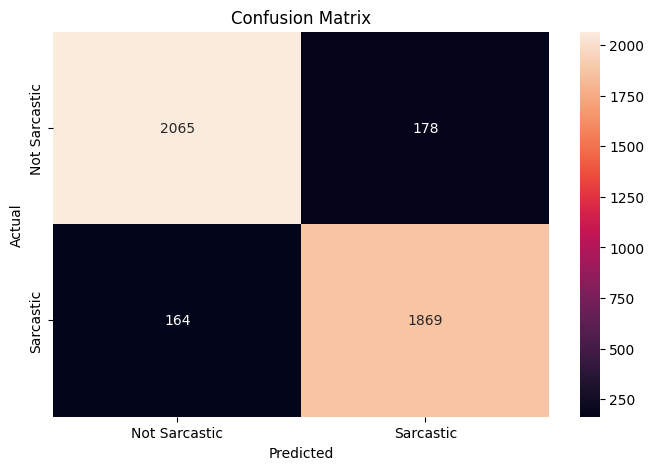

In [71]:
print("DistilBERT Test Performance:")
metric_score(y_test, y_pred_bert)

### **Observations**
- DistilBERT achieved **92% test accuracy**, demonstrating strong generalization on unseen data.
- Precision, recall, and F1-scores are consistently around **0.92** for both classes, indicating balanced performance without significant class bias.
- The high performance highlights DistilBERT's ability to capture contextual information, making it well suited for sarcasm detection.

# **Comparing model performances**

In [73]:
# Logistic Regression metrics
lr_acc = accuracy_score(y_test, y_test_pred)
lr_precision = precision_score(y_test, y_test_pred, average='weighted')
lr_recall = recall_score(y_test, y_test_pred, average='weighted')
lr_f1 = f1_score(y_test, y_test_pred, average='weighted')

# tuned Logistic Regression metrics
lr_tuned_acc = accuracy_score(y_test, y_test_pred_tuned)
lr_tuned_precision = precision_score(y_test, y_test_pred_tuned, average='weighted')
lr_tuned_recall = recall_score(y_test, y_test_pred_tuned, average='weighted')
lr_tuned_f1 = f1_score(y_test, y_test_pred_tuned, average='weighted')

# DistilBERT metrics
bert_acc = accuracy_score(y_test, y_pred_bert)
bert_precision = precision_score(y_test, y_pred_bert, average='weighted')
bert_recall = recall_score(y_test, y_pred_bert, average='weighted')
bert_f1 = f1_score(y_test, y_pred_bert, average='weighted')

In [74]:
comparison_frame = pd.DataFrame({
    'Model': ['TF-IDF + Logistic Regression (default)', 'TF-IDF + Logistic Regression (tuned)', 'DistilBERT (Fine-tuned)'],
    'Accuracy': [lr_acc, lr_tuned_acc, bert_acc],
    'Precision': [lr_precision, lr_tuned_precision, bert_precision],
    'Recall': [lr_recall, lr_tuned_recall, bert_recall],
    'F1 Score': [lr_f1, lr_tuned_f1, bert_f1]
})

# Round to 4 decimal places for clean display
comparison_frame = comparison_frame.round(4)
comparison_frame

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression (default),0.7734,0.7736,0.7734,0.7729
1,TF-IDF + Logistic Regression (tuned),0.7739,0.7738,0.7739,0.7736
2,DistilBERT (Fine-tuned),0.9200,0.9201,0.9200,0.9200


### **Observations**
- Both TF-IDF + Logistic Regression models — default and tuned — landed at almost the same accuracy (77.3% vs 77.4%), confirming that bigrams and tuning `C` didn't meaningfully help.
- DistilBERT jumped to 92% accuracy, a clear improvement over both LR versions across every metric.
- This gap makes sense given what the earlier error analysis showed — TF-IDF only sees word frequency, while DistilBERT picks up on context, which is what sarcasm actually depends on.

# **Error analysis of DistilBERT model**

In [59]:
# Create a dataframe of test headlines with actual and predicted labels
results_df = pd.DataFrame({
    'headline': list(X_test),
    'actual': list(y_test),
    'predicted': y_pred_bert
})

# Filter only misclassified examples
misclassified = results_df[results_df['actual'] != results_df['predicted']].reset_index(drop=True)

print(f"Total misclassified: {len(misclassified)} out of {len(results_df)}")
print(f"Misclassification rate: {len(misclassified)/len(results_df)*100:.2f}%")

Total misclassified: 342 out of 4276
Misclassification rate: 8.00%


In [60]:
# Type 1 — Model predicted Sarcastic but was actually Not Sarcastic (False Positive)
false_positives = misclassified[misclassified['predicted'] == 1].reset_index(drop=True)

# Type 2 — Model predicted Not Sarcastic but was actually Sarcastic (False Negative)
false_negatives = misclassified[misclassified['predicted'] == 0].reset_index(drop=True)

print(f"False Positives (predicted Sarcastic, actually Not): {len(false_positives)}")
print(f"False Negatives (predicted Not Sarcastic, actually Sarcastic): {len(false_negatives)}")

False Positives (predicted Sarcastic, actually Not): 178
False Negatives (predicted Not Sarcastic, actually Sarcastic): 164


In [61]:
print("=== FALSE POSITIVES (predicted Sarcastic, actually Not Sarcastic) ===")
for i, row in false_positives.head(8).iterrows():
    print(f"{i+1}. {row['headline']}")

print("\n=== FALSE NEGATIVES (predicted Not Sarcastic, actually Sarcastic) ===")
for i, row in false_negatives.head(8).iterrows():
    print(f"{i+1}. {row['headline']}")

=== FALSE POSITIVES (predicted Sarcastic, actually Not Sarcastic) ===
1. netflix to shut down planned louis c.k. comedy special
2. whatsapp to phase out subscription fees
3. frat suspended after 'rape some b*****s' comment caught on tape
4. president obama: pretty sure jesus isn't cool with the drones
5. poll signals trouble for gop in blockading supreme court
6. texas lt. gov. not worried about bathroom bill costing the state money
7. peter dinklage might've spit his gum into wife's mouth before accepting his emmy
8. kansas city-area waiter gets world series ticket as a tip

=== FALSE NEGATIVES (predicted Not Sarcastic, actually Sarcastic) ===
1. ann coulter attacks trump for cowardly backing down from full on race war
2. reno orders investigation of u.s. department of corruption
3. lives of mitch mcconnell, john boehner, eric cantor retain meaning
4. gwyneth paltrow reported as news
5. pallbearers carry leslie nielsen's coffin without incident
6. your republican friend to explain why

### **Observations**

*  Total misclassification rate: 8.00% (342/4276)
*  False positives (178) slightly outnumber false negatives (164).
*  False positives are mostly plain, dry headlines, not humorous ones — a Netflix cancellation, a WhatsApp pricing change, a poll, a waiter's tip. Only a couple (Dinklage's gum comment, Obama/drones) are genuinely quirky. Suggests the model reacts to unusual wording in general, not just humor.
*  Most false negatives need knowledge of a public figure's reputation to catch the irony (Coulter, McConnell, Paltrow, Nielsen, Ryan, Ashcroft) — though a few rely on wordplay or cultural knowledge instead (Reno/"corruption", North Dakota flooding).
*  Overall, DistilBERT still struggles when sarcasm depends on outside knowledge rather than the text itself. A larger, more diverse dataset covering more figures and contexts could help close this gap.

# **Pushing to Hugging Face hub**

In [62]:
from huggingface_hub import login
login()

In [63]:
# Save fine-tuned model and tokenizer to a local directory
model.save_pretrained('./sarcasm-distilbert')
tokenizer.save_pretrained('./sarcasm-distilbert')

print("Model and tokenizer saved locally.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved locally.


In [64]:
# Define label mapping explicitly before pushing
model.config.id2label = {0: "Not Sarcastic", 1: "Sarcastic"}
model.config.label2id = {"Not Sarcastic": 0, "Sarcastic": 1}

#push to hub
model.push_to_hub("sarcasm-distilbert")
tokenizer.push_to_hub("sarcasm-distilbert")

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...6p_7rbv/model.safetensors:   2%|2         | 6.46MB /  268MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/satyame639291/sarcasm-distilbert/commit/2294b08cfd16e38461adc9fc1d30afe515ede841', commit_message='Upload tokenizer', commit_description='', oid='2294b08cfd16e38461adc9fc1d30afe515ede841', pr_url=None, repo_url=RepoUrl('https://huggingface.co/satyame639291/sarcasm-distilbert', endpoint='https://huggingface.co', repo_type='model', repo_id='satyame639291/sarcasm-distilbert'), pr_revision=None, pr_num=None)

# **Inference Test**

In [65]:
# Quick test to confirm saved model loads and predicts correctly
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="satyame639291/sarcasm-distilbert"
)

# Test on a few custom headlines
test_headlines = [
    "inclement weather prevents liar from getting to work",   # Sarcastic
    "eat your veggies: 9 deliciously different recipes",      # Not Sarcastic
    "ford develops new suv that runs purely on gasoline",     # Sarcastic
    "how to live to be 110"                                   # Not Sarcastic
]

for headline in test_headlines:
    result = classifier(headline)[0]
    label = result['label']
    print(f"Headline: {headline}")
    print(f"Prediction: {label} (confidence: {result['score']*100:.2f}%)\n")

config.json:   0%|          | 0.00/796 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

Headline: inclement weather prevents liar from getting to work
Prediction: Sarcastic (confidence: 99.54%)

Headline: eat your veggies: 9 deliciously different recipes
Prediction: Not Sarcastic (confidence: 99.74%)

Headline: ford develops new suv that runs purely on gasoline
Prediction: Sarcastic (confidence: 99.02%)

Headline: how to live to be 110
Prediction: Not Sarcastic (confidence: 99.81%)

